# Pretrained baselines with SAM — ResNet18, ViT‑B/16
- Fine‑tuning + SAM (ρ≈0.05), LLRD for ViT head, recall‑first evaluation.

In [1]:
# Clean imports + path setup
import sys
from pathlib import Path
import warnings

# tqdm: prefer notebook widgets, fallback to text
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists():
        break
    proj_root = proj_root.parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))
print("sys.path[0] =", sys.path[0])

# Weights path
weights_path = proj_root / "notebooks" / "weights" / "ViT-B_16.npz"
print("weights:", weights_path)

# Project imports
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project
weights: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project/notebooks/weights/ViT-B_16.npz


device(type='mps')

In [2]:
# === Paths/config ===
DATASET_DIR = Path("../Data/chest_xray")  # <--- edit if needed

# Use the SAME split settings as scratch for fairness
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=0,             # use 0 if you're on Windows/limited env; 2+ is fine otherwise
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,            # keep consistent across notebooks
    gray_to_rgb=True,          # convert grayscale to 3-ch to match pretrained weights
    compute_norm_stats=False,  # use ImageNet mean/std to match pretrained models
    balance_sampler=True
)

# Pretrained + SAM fine-tune defaults
pretrain_sam_cfg = TrainCfg(
    epochs=20, patience=5, monitor="va_auroc",
    base_lr=1e-4, weight_decay=1e-4,      # conservative finetune with SAM
    clip_grad_norm=1.0, use_amp=False,    # set True if your setup supports AMP
    use_sam=True, sam_rho=0.05,           # default rho here; ViT will override to 0.20
    use_cosine=True, warmup_epochs=2, min_lr_mult=0.05,
    target_recall=0.95,
    llrd=True, head_lr_mult=10.0,         # faster classifier head (esp. ViT)
    vit_npz_path=weights_path
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Imbalance handling: with balance_sampler=True, avoid class_weights to prevent double-weighting
class_weights = None


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]


[ResNet18-pretrained+SAM] epoch 01/20  tr_loss=0.6414  val_loss=0.6024  val_acc=0.6886  val_f1=0.7627  val_auroc=0.7845  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 02/20  tr_loss=0.5901  val_loss=0.5628  val_acc=0.7373  val_f1=0.7946  val_auroc=0.8841  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 03/20  tr_loss=0.5326  val_loss=0.5072  val_acc=0.7908  val_f1=0.8393  val_auroc=0.9324  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 04/20  tr_loss=0.4847  val_loss=0.4679  val_acc=0.8252  val_f1=0.8690  val_auroc=0.9342  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 05/20  tr_loss=0.4469  val_loss=0.4204  val_acc=0.8329  val_f1=0.8754  val_auroc=0.9523  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 06/20  tr_loss=0.4274  val_loss=0.3964  val_acc=0.8500  val_f1=0.8898  val_auroc=0.9530  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 07/20  tr_loss=0.4075  val_loss=0.3639  val_acc=0.8634  val_f1=0.9003  val_auroc=0.9606  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 08/20  tr_loss=0

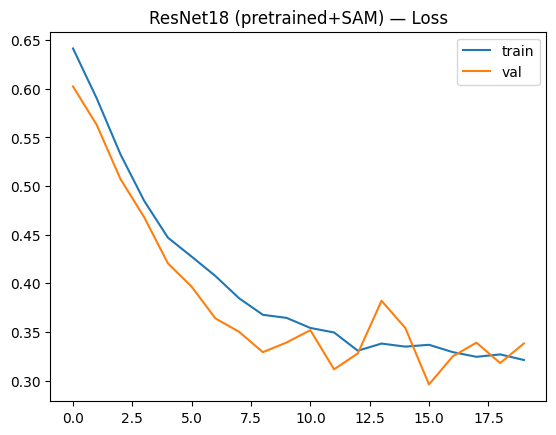

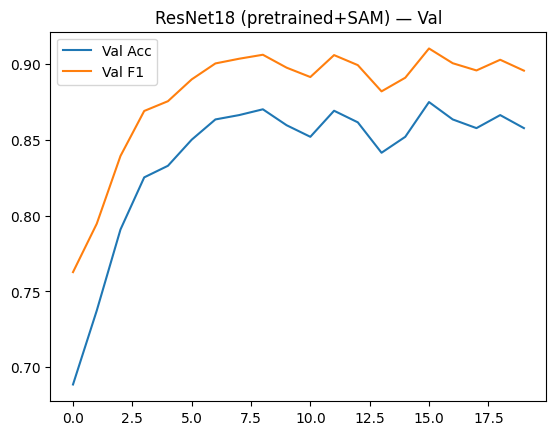

[ResNet18-pretrained+SAM @0.5] {'acc': 0.8429, 'precision': 0.8763, 'recall': 0.8718, 'f1': 0.874, 'auroc': 0.9073, 'thr': 0.5}
[ResNet18-pretrained+SAM @Rec] {'acc': 0.7821, 'precision': 0.751, 'recall': 0.9744, 'f1': 0.8482, 'auroc': 0.9073, 'thr': 0.1545}


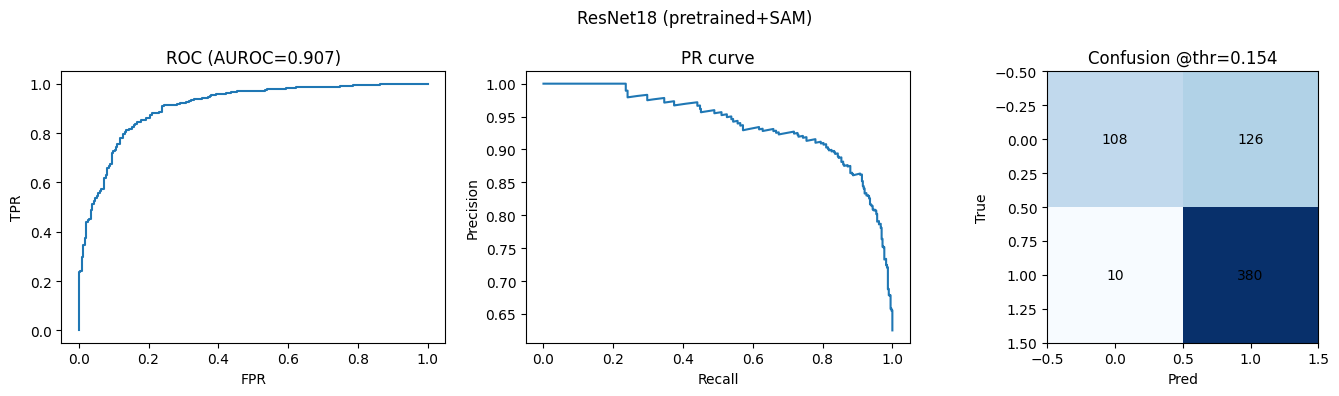

{'summary@0.5': {'acc': 0.842948717948718,
  'precision': 0.8762886597938144,
  'recall': 0.8717948717948718,
  'f1': 0.8740359897172236,
  'auroc': 0.9073197457812843,
  'thr': 0.5},
 'summary@recall': {'acc': 0.782051282051282,
  'precision': 0.7509881422924901,
  'recall': 0.9743589743589743,
  'f1': 0.8482142857142857,
  'auroc': 0.9073197457812843,
  'thr': 0.1545},
 'threshold': 0.1545,
 'time_sec': 5152.080456972122,
 'params': 11177538}

In [3]:
cfg = pretrain_sam_cfg

rn = build_resnet18(in_chans=3, num_classes=2, pretrained=True, conv_stem=False)

t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=cfg.epochs,
    base_lr=cfg.base_lr, weight_decay=cfg.weight_decay, label_smoothing=0.0,
    use_sam=True, sam_rho=0.05,                        # small rho for CNNs
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-pretrained+SAM"
)
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (pretrained+SAM) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (pretrained+SAM) — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-pretrained+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-pretrained+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (pretrained+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (pretrained+SAM)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-B/16-pretrained+SAM] epoch 01/20  tr_loss=0.5755  val_loss=0.6003  val_acc=0.6944  val_f1=0.7415  val_auroc=0.9633  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 02/20  tr_loss=0.4448  val_loss=0.4197  val_acc=0.8281  val_f1=0.8696  val_auroc=0.9683  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 03/20  tr_loss=0.4244  val_loss=0.3943  val_acc=0.8214  val_f1=0.8636  val_auroc=0.9746  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 04/20  tr_loss=0.3836  val_loss=0.4668  val_acc=0.7861  val_f1=0.8321  val_auroc=0.9728  (no_improve=1)
[ViT-B/16-pretrained+SAM] epoch 05/20  tr_loss=0.3710  val_loss=0.2613  val_acc=0.8978  val_f1=0.9282  val_auroc=0.9689  (no_improve=2)
[ViT-B/16-pretrained+SAM] epoch 06/20  tr_loss=0.3451  val_loss=0.3997  val_acc=0.8309  val_f1=0.8722  val_auroc=0.9746  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 07/20  tr_loss=0.3294  val_loss=0.2962  val_acc=0.8720  val_f1=0.9069  val_auroc=0.9751  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 08/20  tr_loss=0

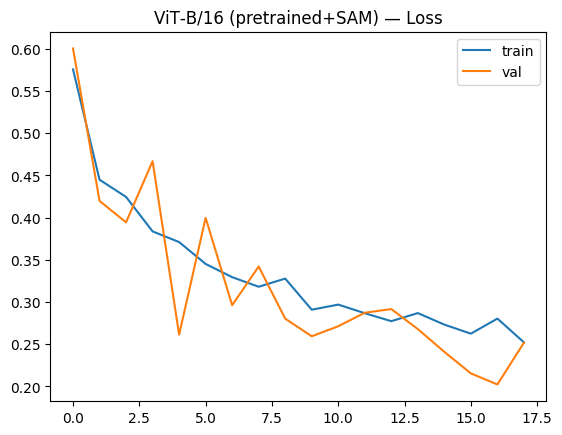

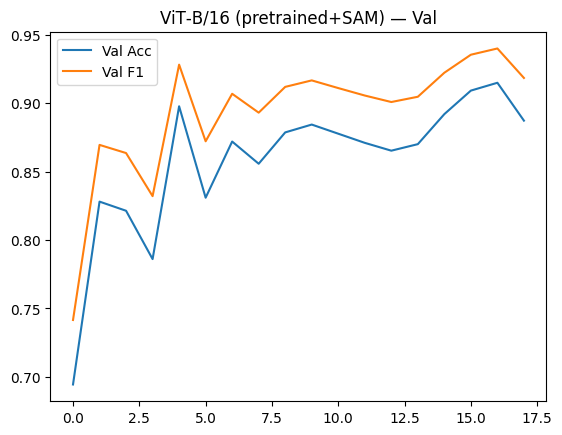

[ViT-B/16-pretrained+SAM @0.5] {'acc': 0.867, 'precision': 0.8987, 'recall': 0.8872, 'f1': 0.8929, 'auroc': 0.9298, 'thr': 0.5}
[ViT-B/16-pretrained+SAM @Rec] {'acc': 0.851, 'precision': 0.8235, 'recall': 0.9692, 'f1': 0.8905, 'auroc': 0.9298, 'thr': 0.1455}


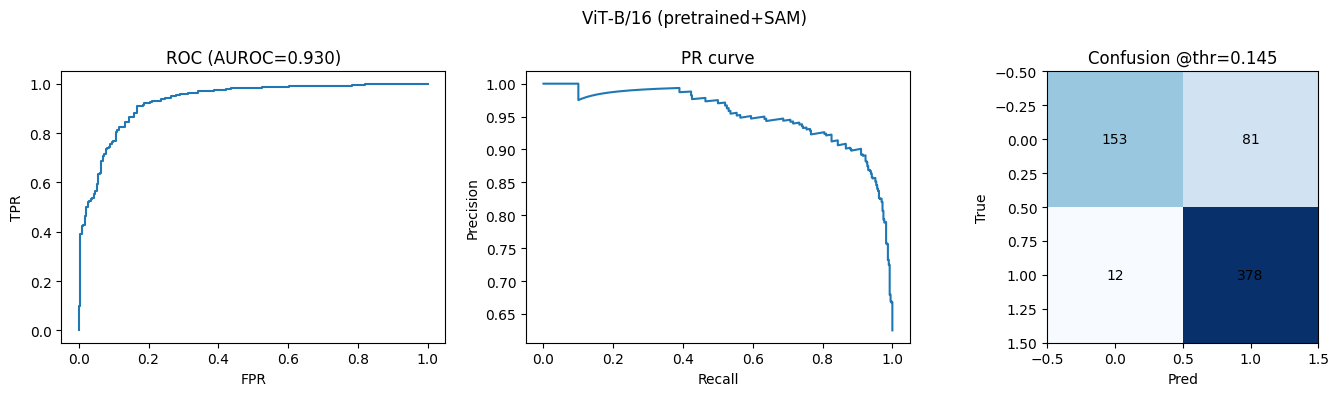

In [4]:
try:
    vit = build_vit_pretrained(
        num_classes=2, model_name="vit_base_patch16_224",
        pretrained=True, npz_path=pretrain_sam_cfg.vit_npz_path
    )
except Exception as e:
    print("ViT‑B/16 pretrained unavailable (no timm and no .npz). Skipping ViT cell.")
    vit = None

if vit is not None:
    t0 = time.time()
    vit_tr, vit_hist, vit_time = train_model(
        vit, train_loader, val_loader, DEVICE, arch="vit",
        epochs=pretrain_sam_cfg.epochs,
        base_lr=pretrain_sam_cfg.base_lr, weight_decay=pretrain_sam_cfg.weight_decay, label_smoothing=0.0,
        use_sam=True, sam_rho=0.20,  # larger rho for ViT-B/16 (per Table 11)
        use_cosine=pretrain_sam_cfg.use_cosine, warmup_epochs=pretrain_sam_cfg.warmup_epochs, min_lr_mult=pretrain_sam_cfg.min_lr_mult,
        monitor=pretrain_sam_cfg.monitor, patience=pretrain_sam_cfg.patience, clip_grad_norm=pretrain_sam_cfg.clip_grad_norm,
        class_weights=class_weights, llrd=pretrain_sam_cfg.llrd, head_lr_mult=pretrain_sam_cfg.head_lr_mult, use_amp=pretrain_sam_cfg.use_amp,
        tag="ViT-B/16-pretrained+SAM"
    )
    vit_time = time.time() - t0

    plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT‑B/16 (pretrained+SAM) — Loss")
    plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT‑B/16 (pretrained+SAM) — Val")

    va = evaluate(vit_tr, val_loader, DEVICE)
    thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], pretrain_sam_cfg.target_recall)
    te = evaluate(vit_tr, test_loader, DEVICE)
    sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
    sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
    print("[ViT-B/16-pretrained+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
    print("[ViT-B/16-pretrained+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
    diag_plots("ViT‑B/16 (pretrained+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
    add_result("ViT‑B/16 (pretrained+SAM)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [5]:
import pandas as pd
from src import result_registry as RR

rows=[]
for name, d in RR.items():
    s = d.get("summary@recall", d.get("summary@0.5"))
    if not s: 
        continue
    thr = d.get("threshold", s.get("thr", 0.5))
    rows.append({
        "Model": name,
        "Params (M)": round(d.get("params", 0)/1e6, 2) if d.get("params") else None,
        "Time (min)": round(d.get("time_sec", 0)/60, 2) if d.get("time_sec") else None,
        "Acc": round(s["acc"],4), "Prec": round(s["precision"],4),
        "Recall": round(s["recall"],4), "F1": round(s["f1"],4),
        "AUROC": round(s.get("auroc", float('nan')),4), "Thr": round(thr,3)
    })
df = pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ViT‑B/16 (pretrained+SAM),85.80,298.64,0.8510,0.8235,0.9692,0.8905,0.9298,0.145
1,ResNet18 (pretrained+SAM),11.18,85.87,0.7821,0.7510,0.9744,0.8482,0.9073,0.154


                    Model  Params (M)  Time (min)    Acc   Prec  Recall     F1  AUROC   Thr
ViT‑B/16 (pretrained+SAM)       85.80      298.64 0.8510 0.8235  0.9692 0.8905 0.9298 0.145
ResNet18 (pretrained+SAM)       11.18       85.87 0.7821 0.7510  0.9744 0.8482 0.9073 0.154
